# Hands-on Task 1: Autoencoder Representation Learning

1. Load Data

In [16]:
# Download MNIST before running the original data-loading cell.
import ssl
import urllib.request
import certifi
from torchvision import datasets, transforms

# Use trusted certificates for HTTPS downloads.
context = ssl.create_default_context(cafile=certifi.where())
urllib.request.install_opener(
    urllib.request.build_opener(
        urllib.request.HTTPSHandler(context=context)
    )
)

data_root = "/Users/kenny/Research/notebook/research-preparation-federated-clustering/data"

# Use the Google-hosted mirror; torchvision verifies file checksums.
datasets.MNIST.mirrors = ["https://storage.googleapis.com/cvdf-datasets/mnist/"]

train_dataset = datasets.MNIST(
    root=data_root,
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

test_dataset = datasets.MNIST(
    root=data_root,
    train=False,
    download=True,
    transform=transforms.ToTensor(),
)

print("Training samples:", len(train_dataset))  # 60000
print("Test samples:", len(test_dataset))       # 10000


Training samples: 60000
Test samples: 10000


In [17]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="/Users/kenny/Research/notebook/research-preparation-federated-clustering/data",
    train=True,
    download=False,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="/Users/kenny/Research/notebook/research-preparation-federated-clustering/data",
    train=False,
    download=False,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,#randomly shuffle the data at every epoch
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,#do not shuffle the data for testing
)

2. Build AE

In [18]:
from torch import nn

class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),                 
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),     
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),                 
            nn.Unflatten(1, (1, 28, 28)),  
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed


model = Autoencoder(latent_dim=16)

3. Train the AE to reconstruct the input

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()#损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)#优化器，learning rate = 0.001

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0

    # 每次取出一批图片和对应标签
    for images, _ in train_loader:
        images = images.to(device)
        #清空上次的梯度
        optimizer.zero_grad()
        #前向传播，得到重建的图片
        reconstructed = model(images)
        #计算损失函数
        loss = criterion(reconstructed, images)
        #反向传播，计算梯度
        loss.backward()
        #更新参数
        optimizer.step()
        #累计训练损失
        train_loss += loss.item() * images.size(0)

    #计算平均训练损失
    average_loss = train_loss / len(train_loader.dataset)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {average_loss:.4f}")

Epoch [1/10], Loss: 0.0685
Epoch [2/10], Loss: 0.0343
Epoch [3/10], Loss: 0.0254
Epoch [4/10], Loss: 0.0226
Epoch [5/10], Loss: 0.0202
Epoch [6/10], Loss: 0.0183
Epoch [7/10], Loss: 0.0170
Epoch [8/10], Loss: 0.0160
Epoch [9/10], Loss: 0.0152
Epoch [10/10], Loss: 0.0145


4. Display original samples and reconstructed samples（10 samples）

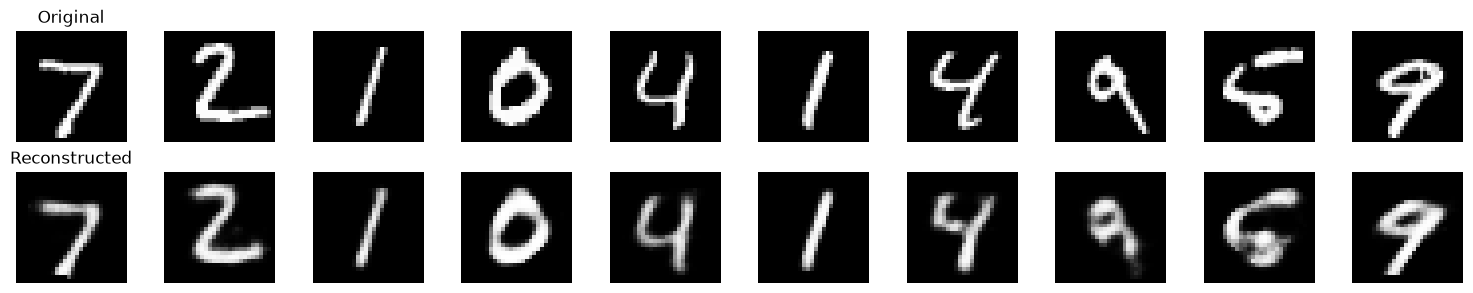

In [20]:
import matplotlib.pyplot as plt

model.eval()

images, _ = next(iter(test_loader))
images = images[:10]

with torch.no_grad():
    reconstructed = model(images.to(device)).cpu()

fig, axes = plt.subplots(2, 10, figsize=(15, 3))

for i in range(10):
    
    axes[0, i].imshow(
        images[i, 0].cpu().numpy(),
        cmap="gray", vmin=0, vmax=1
    )

    axes[1, i].imshow(
        reconstructed[i, 0].numpy(),
        cmap="gray", vmin=0, vmax=1
    )

    axes[0, i].axis("off")
    axes[1, i].axis("off")

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")

plt.tight_layout()
plt.show()

5. Extract the latent representations

In [21]:
# 分别保存每个批次的特征和真实标签
latent_batches = []
label_batches = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # 这里只调用编码器，不需要解码器
        # [batch_size, 1, 28, 28] → [batch_size, 16]
        z = model.encoder(images)

        # 移到 CPU，保存当前批次的结果
        latent_batches.append(z.cpu())

        # 同时保存对应标签，保证特征与标签顺序一致
        # 标签只用于最后评价，不参与特征提取或聚类
        label_batches.append(labels.cpu())

# 沿第 0 维拼接，把多个批次合成一个完整数组
Z = torch.cat(latent_batches, dim=0).numpy()
y_true = torch.cat(label_batches, dim=0).numpy()

6. Apply K-means to the latent representations and Calculate ARI and NMI using labels only for final evaluation.

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# MNIST 有 10 个数字类别，这里预先设置聚成 10 簇
kmeans = KMeans(n_clusters=10, n_init=10, random_state=47)

# 只使用 16 维特征进行聚类，没有传入真实标签
# 返回每张图片所属的簇，形状为 (10000,)
cluster_labels = kmeans.fit_predict(Z)

# 聚类结束后，才使用真实标签评价结果
ari = adjusted_rand_score(y_true, cluster_labels)
nmi = normalized_mutual_info_score(y_true, cluster_labels)

print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")

ARI: 0.2895
NMI: 0.4223


above is 16 dimension, follow let's try 8 and 32 dimension

In [23]:
# 创建新的 8 维 AE，并为它创建优化器
model_8 = Autoencoder(latent_dim=8).to(device)
optimizer_8 = torch.optim.Adam(model_8.parameters(), lr=1e-3)

# 训练
for epoch in range(epochs):
    model_8.train()
    train_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer_8.zero_grad()
        reconstructed = model_8(images)
        loss = criterion(reconstructed, images)
        loss.backward()
        optimizer_8.step()

        train_loss += loss.item() * images.size(0)

    average_loss = train_loss / len(train_loader.dataset)
    print(f"AE-8, Epoch {epoch + 1}/{epochs}, Loss: {average_loss:.4f}")

# 提取测试图片的 8 维特征
latent_batches_8 = []
label_batches_8 = []

model_8.eval()
with torch.no_grad():
    for images, labels in test_loader:
        z = model_8.encoder(images.to(device))  # [batch_size, 8]
        latent_batches_8.append(z.cpu())
        label_batches_8.append(labels.cpu())

Z_8 = torch.cat(latent_batches_8, dim=0).numpy()
y_true_8 = torch.cat(label_batches_8, dim=0).numpy()

# 只使用特征进行聚类
kmeans_8 = KMeans(n_clusters=10, n_init=10, random_state=47)
cluster_labels_8 = kmeans_8.fit_predict(Z_8)

# 真实标签只用于最终评价
ari_8 = adjusted_rand_score(y_true_8, cluster_labels_8)
nmi_8 = normalized_mutual_info_score(y_true_8, cluster_labels_8)

print(f"AE-8: ARI={ari_8:.4f}, NMI={nmi_8:.4f}")

AE-8, Epoch 1/10, Loss: 0.0674
AE-8, Epoch 2/10, Loss: 0.0354
AE-8, Epoch 3/10, Loss: 0.0292
AE-8, Epoch 4/10, Loss: 0.0268
AE-8, Epoch 5/10, Loss: 0.0253
AE-8, Epoch 6/10, Loss: 0.0242
AE-8, Epoch 7/10, Loss: 0.0232
AE-8, Epoch 8/10, Loss: 0.0224
AE-8, Epoch 9/10, Loss: 0.0218
AE-8, Epoch 10/10, Loss: 0.0213
AE-8: ARI=0.2642, NMI=0.3950


In [25]:
# 创建新的 32 维 AE，并为它创建优化器
model_32 = Autoencoder(latent_dim=32).to(device)
optimizer_32 = torch.optim.Adam(model_32.parameters(), lr=1e-3)

# 训练
for epoch in range(epochs):
    model_32.train()
    train_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer_32.zero_grad()
        reconstructed = model_32(images)
        loss = criterion(reconstructed, images)
        loss.backward()
        optimizer_32.step()

        train_loss += loss.item() * images.size(0)

    average_loss = train_loss / len(train_loader.dataset)
    print(f"AE-32, Epoch {epoch + 1}/{epochs}, Loss: {average_loss:.4f}")

# 提取测试图片的 32 维特征
latent_batches_32 = []
label_batches_32 = []

model_32.eval()
with torch.no_grad():
    for images, labels in test_loader:
        z = model_32.encoder(images.to(device))  # [batch_size, 32]
        latent_batches_32.append(z.cpu())
        label_batches_32.append(labels.cpu())

Z_32 = torch.cat(latent_batches_32, dim=0).numpy()
y_true_32 = torch.cat(label_batches_32, dim=0).numpy()

# 只使用特征进行聚类
kmeans_32 = KMeans(n_clusters=10, n_init=10, random_state=47)
cluster_labels_32 = kmeans_32.fit_predict(Z_32)

# 真实标签只用于最终评价
ari_32 = adjusted_rand_score(y_true_32, cluster_labels_32)
nmi_32 = normalized_mutual_info_score(y_true_32, cluster_labels_32)

print(f"AE-32: ARI={ari_32:.4f}, NMI={nmi_32:.4f}")

AE-32, Epoch 1/10, Loss: 0.0679
AE-32, Epoch 2/10, Loss: 0.0340
AE-32, Epoch 3/10, Loss: 0.0267
AE-32, Epoch 4/10, Loss: 0.0228
AE-32, Epoch 5/10, Loss: 0.0205
AE-32, Epoch 6/10, Loss: 0.0188
AE-32, Epoch 7/10, Loss: 0.0174
AE-32, Epoch 8/10, Loss: 0.0162
AE-32, Epoch 9/10, Loss: 0.0153
AE-32, Epoch 10/10, Loss: 0.0144
AE-32: ARI=0.2390, NMI=0.4009


7. Compare clustering

In [26]:
#raw
# 训练图片：用于学习 PCA 的投影方向
train_batches = []

for images, _ in train_loader:
    # [batch_size, 1, 28, 28] → [batch_size, 784]
    train_batches.append(images.flatten(start_dim=1))

X_train_raw = torch.cat(train_batches, dim=0).numpy()

# 测试图片：三种方法都在这些图片上聚类
test_batches = []
test_label_batches = []

for images, labels in test_loader:
    test_batches.append(images.flatten(start_dim=1))
    test_label_batches.append(labels)

X_raw = torch.cat(test_batches, dim=0).numpy()
y_eval = torch.cat(test_label_batches, dim=0).numpy()

# 确认之前提取的 AE 特征与当前测试图片的标签顺序一致
assert (y_true == y_eval).all()
assert (y_true_8 == y_eval).all()
assert (y_true_32 == y_eval).all()

In [27]:
#pca
from sklearn.decomposition import PCA

pca = PCA(
    n_components=32,
    svd_solver="randomized",
    random_state=47
)

# 学习过程不使用数字标签
pca.fit(X_train_raw)

# 将测试图片从 784 维降到 32 维
X_pca_32 = pca.transform(X_raw)

# 主成分按解释方差从大到小排列
# 取前 8、16 列，分别得到对应维度的 PCA 特征
X_pca_8 = X_pca_32[:, :8]
X_pca_16 = X_pca_32[:, :16]

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# 每个数组的每一行，都对应同一张测试图片
feature_sets = {
    "Raw": X_raw,
    "PCA-8": X_pca_8,
    "AE-8": Z_8,
    "PCA-16": X_pca_16,
    "AE-16": Z,
    "PCA-32": X_pca_32,
    "AE-32": Z_32,
}

results = []

for name, features in feature_sets.items():
    # 各种特征使用相同的聚类设置
    kmeans = KMeans(n_clusters=10, n_init=10, random_state=47)
    cluster_labels = kmeans.fit_predict(features)

    # 聚类结束后，才使用真实标签评价
    score_ari = adjusted_rand_score(y_eval, cluster_labels)
    score_nmi = normalized_mutual_info_score(y_eval, cluster_labels)

    # 保存方法名、特征维度、ARI 和 NMI
    results.append((name, features.shape[1], score_ari, score_nmi))

# 打印对比表
print(f"{'Method':<10} {'Dim':>5} {'ARI':>10} {'NMI':>10}")

for name, dim, score_ari, score_nmi in results:
    print(f"{name:<10} {dim:>5} {score_ari:>10.4f} {score_nmi:>10.4f}")

Method       Dim        ARI        NMI
Raw          784     0.3820     0.5035
PCA-8          8     0.3629     0.4836
AE-8           8     0.2642     0.3950
PCA-16        16     0.3744     0.5032
AE-16         16     0.2895     0.4223
PCA-32        32     0.3815     0.5007
AE-32         32     0.2390     0.4009


Explain how latent dimension affects reconstruction and clustering.

Ans: 

For reconstruction, the smaller the dimension, the stronger the compression, and the easier it is for the model to lose details; the larger the dimension, the more information it usually retains, and the reconstruction error is lower.

For clustering, having more dimensions isn't necessarily better. Adding dimensions might keep useful numerical patterns, but it could also preserve differences unrelated to the categories, which affects K-means distance calculations.
